# Classical vs Quantum Plays Nim

**COMP47950 Quantum Machine Learning — Implementation Notebook & Report**

## 1. Introduction

This project compares **classical** and **quantum** machine learning approaches on the game of **Nim** (normal play, $k = 3$ heaps, max heap size $M = 7$). The ML task is to predict whether a board position is **winning or losing** (Option B: state $\to$ win/loss classification based on Nim-sum), then use the prediction to select moves.

**Four pipelines:**
1. Classical ML baseline (SVM, Random Forest, Logistic Regression)
2. Quantum kernel SVM (isolates the value of the quantum feature map)
3. Simulated VQC (variational quantum classifier with angle and binary encoding)
4. Quantum device inference (IBM Quantum, inference-only)

**Central hypothesis (sample efficiency):** Nim-sum is an XOR/parity function over heap sizes — a structure that parity-aware quantum feature maps may exploit, allowing QML to reach comparable performance with fewer training samples than classical models.

**Secondary experiment (OOD generalisation):** Train on smaller board sizes ($M \leq 5$), test on larger unseen boards ($M = 6, 7$) to assess whether models learn the Nim-sum rule rather than memorising training data.

**Comparison metrics:** Balanced accuracy, Matthews correlation coefficient (MCC), win rate (vs random), sample efficiency (accuracy and win rate vs training set size), OOD accuracy, cost, speed, and interpretability.

In [8]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

from qml_project import build_circuit, train_classifier
from qml_project.nim import (
    NimState,
    nim_sum,
    is_terminal,
    is_winning,
    legal_moves,
    apply_move,
    optimal_move,
    random_policy,
    optimal_policy,
    play_game,
    play_many,
    generate_dataset,
    prepare_experiment_data,
    class_balance_table,
    iid_split,
    training_subsets,
    ood_split,
    normalise_states,
    enumerate_states,
)

ImportError: cannot import name 'generate_dataset' from 'qml_project.nim' (/home/gelbhart/projects/school/spring/qml/src/qml_project/nim/__init__.py)

## 2. Nim Game and Data

*Supports: Input Transformation & Data Prep (10%)*

### 2.1 Game rules

**Nim** (normal play) is a two-player combinatorial game.  The state is a tuple of $k$ heap sizes $(h_1, h_2, \ldots, h_k)$ with $0 \leq h_i \leq M$.  On each turn the current player chooses one non-empty heap $i$ and removes between 1 and $h_i$ stones from it.  The game ends when all heaps are empty; under **normal play** the player who takes the last stone **wins**.

The game is completely solved by the **Nim-sum** — the bitwise XOR of all heap sizes:

$$n = h_1 \oplus h_2 \oplus \cdots \oplus h_k$$

| Nim-sum | Position | Meaning |
|---------|----------|---------|
| $n \neq 0$ | **Winning** | Current player can always force a win by moving to a state with $n = 0$ |
| $n = 0$ | **Losing** | Every legal move leaves $n \neq 0$, giving the opponent a winning position |

**Primary configuration:** $k = 3$ heaps, maximum heap size $M = 7$.  This yields $(M+1)^k - 1 = 511$ non-terminal states — small enough for exhaustive enumeration yet rich enough for meaningful ML experiments.

The game logic is implemented in `qml_project.nim.game` and supports arbitrary $k$ and $M$.

### 2.2 ML task

The ML task is **state $\to$ win/loss classification** (Option B): given a board position $(h_1, h_2, h_3)$, predict whether the current player is in a winning or losing position.  At play time, a winning prediction triggers the Nim-sum optimal move; a losing prediction triggers a random legal move.

This is simpler than full move prediction (Option A) and aligns with the supervisor's description of "a model that emits a binary response for a given board state."

In [ ]:
rng = np.random.default_rng(42)

state: NimState = (3, 5, 2)
print(f"State:       {state}")
print(f"Nim-sum:     {nim_sum(state)}  (= {state[0]} ⊕ {state[1]} ⊕ {state[2]})")
print(f"Winning:     {is_winning(state)}")
print(f"Legal moves: {len(legal_moves(state))}  (sum of heap sizes)")

move = optimal_move(state, rng)
new_state = apply_move(state, move)
print(f"\nOptimal move: remove {move[1]} from heap {move[0]}")
print(f"New state:   {new_state}  →  Nim-sum = {nim_sum(new_state)}")

losing = (3, 5, 6)
print(f"\nLosing state: {losing}  →  Nim-sum = {nim_sum(losing)}, Winning = {is_winning(losing)}")

State:       (3, 5, 2)
Nim-sum:     4  (= 3 ⊕ 5 ⊕ 2)
Winning:     True
Legal moves: 10  (sum of heap sizes)

Optimal move: remove 4 from heap 1
New state:   (3, 1, 2)  →  Nim-sum = 0

Losing state: (3, 5, 6)  →  Nim-sum = 0, Winning = False


### 2.3 Playing Nim

`play_game` runs a full game between two policies; `play_many` aggregates win statistics over many games.  Below, the optimal (Nim-sum) policy plays 500 games against a random policy from the starting position $(7, 7, 7)$.  Since $7 \oplus 7 \oplus 7 = 7 \neq 0$, the first player (optimal) is in a winning position and should win every game.

In [ ]:
stats = play_many(optimal_policy, random_policy, n_games=500, seed=42)
print(f"Optimal (player A) vs Random (player B)  —  500 games from (7,7,7)")
print(f"  Player A wins: {stats['wins_a']}  ({stats['win_rate_a']:.0%})")
print(f"  Player B wins: {stats['wins_b']}  ({stats['win_rate_b']:.0%})")

rec = stats["games"][0]
print(f"\nExample game ({len(rec)} moves):")
for i, (s, m) in enumerate(zip(rec.states[:-1], rec.moves)):
    player = "A" if i % 2 == 0 else "B"
    print(f"  {s}  →  Player {player} removes {m[1]} from heap {m[0]}")
print(f"  {rec.states[-1]}  →  Player {'A' if rec.winner == 0 else 'B'} wins")

Optimal (player A) vs Random (player B)  —  500 games from (7,7,7)
  Player A wins: 500  (100%)
  Player B wins: 0  (0%)

Example game (7 moves):
  (7, 7, 7)  →  Player A removes 7 from heap 0
  (0, 7, 7)  →  Player B removes 4 from heap 2
  (0, 7, 3)  →  Player A removes 4 from heap 1
  (0, 3, 3)  →  Player B removes 1 from heap 2
  (0, 3, 2)  →  Player A removes 1 from heap 1
  (0, 2, 2)  →  Player B removes 2 from heap 1
  (0, 0, 2)  →  Player A removes 2 from heap 2
  (0, 0, 0)  →  Player A wins


### 2.4 Data generation and class balance

We exhaustively enumerate all non-terminal states for $k = 3$ heaps, $M = 7$, yielding $(M+1)^k - 1 = 511$ states.  Each state is labelled with:

- **Win/loss (Option B):** winning ($\text{Nim-sum} \neq 0$) or losing ($\text{Nim-sum} = 0$).
- **Optimal move index (Option A):** a flat index encoding the move $(h, a) \mapsto h \cdot M + (a - 1)$, giving $k \times M = 21$ possible move classes.

**Class imbalance.**  For $k = 3$ heaps the number of losing positions is $(M+1)^2$ (one per $(h_1, h_2)$ pair, with $h_3 = h_1 \oplus h_2$), minus the terminal state.  At $M = 7$ this gives 63 losing states out of 511 total (**12.3 %**).  The imbalance grows more severe at larger $M$ (see table below), motivating **class-weighted losses** and **balanced accuracy** as the primary metric.

Data generation is implemented in `qml_project.nim.data`.

In [ ]:
dataset = generate_dataset(k=3, M=7, random_state=42)
print(f"Total non-terminal states: {len(dataset)}")
print(f"  Winning: {dataset.is_winning.sum()}  Losing: {(1 - dataset.is_winning).sum()}")
print(f"  Move classes (Option A): {dataset.n_classes_move}")

balance = class_balance_table(M_values=range(1, 8), k=3)
print("\nClass balance by M (k = 3 heaps):")
balance

Total non-terminal states: 511
  Winning: 448  Losing: 63
  Move classes (Option A): 21

Class balance by M (k = 3 heaps):


,M,total,winning,losing,pct_losing
0,1,7,4,3,42.9
1,2,26,20,6,23.1
2,3,63,48,15,23.8
3,4,124,106,18,14.5
4,5,215,188,27,12.6
5,6,342,300,42,12.3
6,7,511,448,63,12.3


The heatmap below fixes $h_3 = 0$ and colours the $(h_1, h_2)$ plane by win (blue) vs loss (orange, Nim-sum $= 0$).  Losing positions lie along $h_1 = h_2$ (since $h_1 \oplus h_2 \oplus 0 = 0 \iff h_1 = h_2$), illustrating the XOR decision boundary that the ML models must learn.

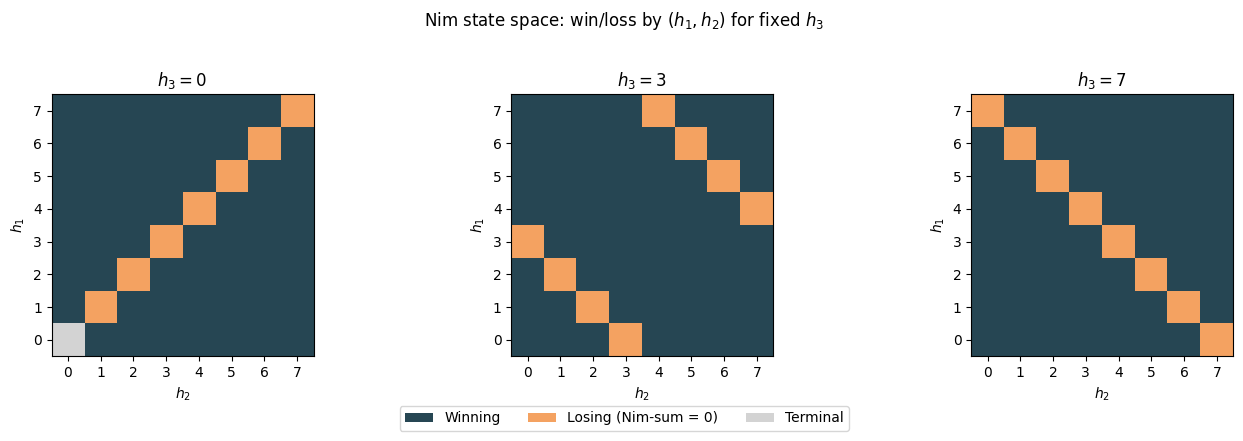

In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(14, 4))
for ax, h3 in zip(axes, [0, 3, 7]):
    grid = np.zeros((8, 8), dtype=int)
    for h1 in range(8):
        for h2 in range(8):
            if (h1, h2, h3) == (0, 0, 0) and h3 == 0:
                grid[h1, h2] = -1
            else:
                grid[h1, h2] = 1 if (h1 ^ h2 ^ h3) != 0 else 0
    cmap = plt.cm.colors.ListedColormap(["lightgrey", "#f4a261", "#264653"])
    im = ax.imshow(grid, origin="lower", cmap=cmap, vmin=-1, vmax=1)
    ax.set_xlabel("$h_2$")
    ax.set_ylabel("$h_1$")
    ax.set_title(f"$h_3 = {h3}$")
    ax.set_xticks(range(8))
    ax.set_yticks(range(8))

from matplotlib.patches import Patch
legend_elements = [Patch(facecolor="#264653", label="Winning"),
                   Patch(facecolor="#f4a261", label="Losing (Nim-sum = 0)"),
                   Patch(facecolor="lightgrey", label="Terminal")]
fig.legend(handles=legend_elements, loc="lower center", ncol=3, bbox_to_anchor=(0.5, -0.05))
fig.suptitle("Nim state space: win/loss by $(h_1, h_2)$ for fixed $h_3$", y=1.02)
plt.tight_layout()
plt.show()

### 2.5 IID splits and training-size subsets

**IID regime (development and sanity check):** a stratified 70 / 15 / 15 train / validation / test split on the $M = 7$ states.  Stratification is on the binary win/loss label so every partition preserves the ~88 / 12 class ratio.

**Sample-efficiency subsets:** stratified sub-samples of the training set at sizes 50, 100, and 200 (the full training set of ~357 is always included).  Each pipeline is trained on every subset with 10+ seeds to produce the central **accuracy vs training size** comparison.

All splits use `random_state=42`.

In [ ]:
iid = iid_split(dataset, random_state=42)

rows = []
for name, X, y in [("Train", iid.X_train, iid.y_train),
                    ("Val",   iid.X_val,   iid.y_val),
                    ("Test",  iid.X_test,  iid.y_test)]:
    n = len(y)
    n_lose = int((1 - y).sum())
    rows.append({"Split": name, "n": n, "Winning": n - n_lose,
                 "Losing": n_lose, "% Losing": f"{100*n_lose/n:.1f}"})
print("IID split (M = 7, stratified by win/loss):")
pd.DataFrame(rows)

IID split (M = 7, stratified by win/loss):


,Split,n,Winning,Losing,% Losing
0,Train,357,313,44,12.3
1,Val,77,68,9,11.7
2,Test,77,67,10,13.0


In [ ]:
subsets = training_subsets(iid.X_train, iid.y_train, sizes=[50, 100, 200],
                          random_state=42)

rows = []
for key in [50, 100, 200, "full"]:
    s = subsets[key]
    n_lose = int((1 - s.y).sum())
    rows.append({"Subset": str(key), "n": s.size, "Winning": s.size - n_lose,
                 "Losing": n_lose, "% Losing": f"{100*n_lose/s.size:.1f}"})
print("Training-size subsets (stratified, for sample-efficiency sweep):")
pd.DataFrame(rows)

Training-size subsets (stratified, for sample-efficiency sweep):


,Subset,n,Winning,Losing,% Losing
0,50,50,44,6,12.0
1,100,100,88,12,12.0
2,200,200,175,25,12.5
3,full,357,313,44,12.3


### 2.6 OOD regime

**Out-of-distribution evaluation (secondary experiment):** train on all non-terminal states with heaps $\leq M_{\text{train}} = 5$ (215 states) and test on states with at least one heap $> 5$ (296 states with heaps $\leq 7$).  This tests whether models learn the Nim-sum rule rather than memorising the training distribution — addressing supervisor feedback on test/train contamination.

Feature normalisation always divides by a fixed $M_{\max} = 7$ so that the $[0, 1]$ feature range is consistent between IID and OOD regimes.

In [ ]:
ood = ood_split(k=3, M_train=5, M_test=7, random_state=42)

rows = []
for name, ds in [("OOD Train (M ≤ 5)", ood.train_dataset),
                 ("OOD Test  (M > 5)", ood.test_dataset)]:
    n = len(ds)
    n_lose = int((1 - ds.is_winning).sum())
    rows.append({"Partition": name, "n": n, "Winning": n - n_lose,
                 "Losing": n_lose, "% Losing": f"{100*n_lose/n:.1f}"})
print(f"OOD split: train on M ≤ {ood.M_train}, test on M > {ood.M_train} (M ≤ {ood.M_test})")
pd.DataFrame(rows)

OOD split: train on M ≤ 5, test on M > 5 (M ≤ 7)


,Partition,n,Winning,Losing,% Losing
0,OOD Train (M ≤ 5),215,188,27,12.6
1,OOD Test (M > 5),296,260,36,12.2


### 2.7 Feature normalisation

Classical features are the raw heap sizes normalised by a fixed $M_{\max} = 7$: $x_i = h_i / M_{\max} \in [0, 1]$.  This global constant ensures the feature range is identical across IID and OOD regimes (training on $M \leq 5$ and testing on $M \leq 7$ use the same denominator).  Quantum angle encoding similarly uses $\theta_i = h_i \cdot \pi / M_{\max}$ (§4).

In [ ]:
X_norm = normalise_states(iid.X_train, M_max=7)
print(f"Normalised training features: shape {X_norm.shape}, "
      f"range [{X_norm.min():.3f}, {X_norm.max():.3f}]")
print(f"Example: heaps {tuple(iid.X_train[0])} → features {tuple(np.round(X_norm[0], 3))}")

Normalised training features: shape (357, 3), range [0.000, 1.000]
Example: heaps (np.int32(7), np.int32(7), np.int32(5)) → features (np.float64(1.0), np.float64(1.0), np.float64(0.714))


## 3. Classical ML Baseline

*Supports: Evaluation & Discussion (15%); baseline for Midterm (10%)*

Three classifiers (SVM with RBF kernel, Random Forest, Logistic Regression) with class weighting for the ~88/12 win/loss imbalance. Includes parity-aware baselines (engineered Nim-sum features), symmetry-augmented variants ($S_3$ permutation augmentation), and a custom kernel aligned to the quantum feature map structure. Reports balanced accuracy, MCC, F1, confusion matrices, win rate vs random, and sample-efficiency curves (accuracy vs training set size, 10+ seeds). Includes OOD evaluation (train $M \leq 5$, test $M = 6, 7$).

## 4. QML Input Transformation

*Supports: Input Transformation & Data Prep (10%)*

Three encoding schemes: (1) Angle encoding on 3 qubits ($\theta_i = h_i \cdot \pi / M$), (2) Binary encoding on 9 qubits (3 bits per heap, entanglement aligned to Nim-sum XOR bit positions), (3) IQP/parity feature map emphasising XOR structure. Fixed normalisation by $M_{\max} = 7$ for OOD consistency. Encoding comparison on accuracy, sample efficiency, and circuit depth.

## 5. QML Model Design

*Supports: QML Model Design & Optimisation (30%)*

At least two distinct VQC ansatze per encoding with different hypotheses about Nim-sum structure. Quantum kernel SVM as a bridge pipeline. Measurement and post-processing strategy (observable, decision rule, loss function). Expressibility (KL divergence from Haar-random), entangling capability (Meyer-Wallach measure), and barren plateau diagnosis (gradient variance vs depth).

## 6. Training and Optimisation

*Supports: QML Model Design & Optimisation (30%)*

COBYLA optimisation (SPSA fallback) with 10+ seeds per configuration. MLflow experiment tracking. Sample-efficiency sweep (train on each subset size: 50, 100, 200, 500, full). Symmetry controlled experiment (raw vs augmented vs canonical vs equivariant). Loss function exploration.

## 7. Experimental Design

*Supports: Experimental Design (20%)*

Noise sweep (depolarising rates 0.001–0.05 + backend-specific noise model from IBM calibration data). Error mitigation: measurement error mitigation (readout correction matrix) and zero-noise extrapolation (ZNE). Shot budget analysis (8192 down to 512 shots). Transfer learning experiment (train $M = 3$, fine-tune $M = 5$, test $M = 7$). Device pipeline design and budget.

## 8. Simulated QML Results

Sample-efficiency curves (accuracy and win rate vs training set size for all pipelines, mean $\pm$ std over 10+ seeds with 95% bootstrap CI). OOD generalisation results (IID vs OOD accuracy comparison). Symmetry experiment results. Quantum kernel matrix visualisations.

## 9. Quantum Device Inference

*Supports: Experimental Design (20%); Evaluation & Discussion (15%)*

IBM Quantum free tier, inference-only (no training on device). Budget-conscious test set (30–50 stratified states, 1024 shots). Measurement error mitigation (readout correction matrix) applied to device results. Three-way comparison: raw device vs readout-corrected device vs simulated noisy results.

## 10. Four-Way Comparison

*Supports: Evaluation Methodology and Discussion of Findings (15%)*

Compare all pipelines (classical, quantum kernel SVM, simulated VQC, device VQC) on: balanced accuracy, MCC, win rate, sample efficiency (central finding), OOD generalisation (secondary), cost (wall-clock time, shots, credits), speed (per-sample latency), interpretability. Formal statistical tests: paired Wilcoxon signed-rank with Bonferroni correction, Cohen's d effect sizes, power-law learning curve fits ($\text{accuracy} \sim a - b \cdot n^{-c}$), 95% bootstrap confidence intervals.

## 11. Discussion

### 11.1 Related Work

QML sample efficiency (Huang et al. 2021), QML for combinatorial games, quantum kernel theory (Schuld & Killoran [18]), noise resilience and shallow circuits ([5], [7], [20]), QML vs classical benchmarks ([8], [10]).

### 11.2 Limitations

Small state space (511 states), deterministic game, limited qubits (3–9), optimiser convergence, shot noise, class imbalance at small sample sizes, no real quantum advantage claim.

### 11.3 Adversarial and Hard-Case Analysis

Confusion geography heatmaps, failure clustering by Nim-sum magnitude, disagreement analysis between pipelines.

## 12. References

- [5] Cincio, L. et al. — Variational hybrid algorithms.
- [7] Fontana, E. et al. — Noise resilience.
- [8] Houssein, E. A. et al. — QML state-of-the-art survey.
- [10] Khan, T. M. & Robles-Kelly, A. — Quantum vs classical ML.
- [13] McClean, J. R. et al. — Barren plateaus in QNNs.
- [18] Schuld, M. & Killoran, N. — Quantum feature spaces.
- [20] Selig, P. et al. — Noisy shallow circuits, angle mapping.
- Huang, H.-Y. et al. (2021) — Power of data in quantum machine learning.
- Sim, S. et al. (2019) — Expressibility and entangling capability of parameterized quantum circuits.